In [1]:
import pandas as pd

df = pd.read_csv('data/PS_20174392719_1491204439457_log.csv')

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
print(df.shape)
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True) * 100

(6362620, 11)


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [3]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

In [4]:
fraud_summary = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_summary['fraud_rate_%'] = (fraud_summary['sum'] / fraud_summary['count']) * 100
fraud_summary

,sum,count,fraud_rate_%
type,,,
CASH_IN,0,1399284,0.000000
CASH_OUT,4116,2237500,0.183955
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000
TRANSFER,4097,532909,0.768799


In [5]:
total_fraud = df['isFraud'].sum()
caught_by_rule = df[df['isFraud'] == 1]['isFlaggedFraud'].sum()

print(f"Total actual fraud cases: {total_fraud}")
print(f"Caught by naive rule: {caught_by_rule}")
print(f"Rule catches: {(caught_by_rule/total_fraud)*100:.2f}% of all fraud")

Total actual fraud cases: 8213
Caught by naive rule: 16
Rule catches: 0.19% of all fraud


In [6]:
fraud_df = df[df['isFraud'] == 1]
drained = (fraud_df['newbalanceOrig'] == 0).sum()
total_fraud = len(fraud_df)

print(f"Fraud cases where sender's balance hit exactly 0: {drained} out of {total_fraud}")
print(f"That's {(drained/total_fraud)*100:.2f}% of all fraud")

Fraud cases where sender's balance hit exactly 0: 8053 out of 8213
That's 98.05% of all fraud


In [7]:
relevant = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print(relevant.head())
relevant.groupby('isFraud')['amount'].describe()

    step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2      1  TRANSFER     181.00  C1305486145          181.0             0.0   
3      1  CASH_OUT     181.00   C840083671          181.0             0.0   
15     1  CASH_OUT  229133.94   C905080434        15325.0             0.0   
19     1  TRANSFER  215310.30  C1670993182          705.0             0.0   
24     1  TRANSFER  311685.89  C1984094095        10835.0             0.0   

       nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
2    C553264065             0.0            0.00        1               0  
3     C38997010         21182.0            0.00        1               0  
15   C476402209          5083.0        51513.44        0               0  
19  C1100439041         22425.0            0.00        0               0  
24   C932583850          6267.0      2719172.89        0               0  


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,2762196.0,3.141155e+05,8.771441e+05,0.01,82908.2325,171034.46,305994.185,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.3300,441423.44,1517771.480,10000000.00


In [8]:
relevant = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
relevant.groupby('isFraud')[['oldbalanceDest', 'newbalanceDest']].describe()

oldbalanceDest                                               \
                 count          mean           std  min         25%   
isFraud                                                               
0            2762196.0  1.706998e+06  4.227442e+06  0.0  129982.425   
1               8213.0  5.442496e+05  3.336421e+06  0.0       0.000   

                                             newbalanceDest                \
               50%         75%           max          count          mean   
isFraud                                                                     
0        558272.99  1740403.81  3.560159e+08      2762196.0  2.052024e+06   
1             0.00   147828.66  2.362305e+08         8213.0  1.279708e+06   

                                                                              
                  std  min        25%        50%           75%           max  
isFraud                                                                       
0        4.678898e+06  0.0  328796.37  829902.93  2.124570e+06  3.561793e+08  
1        3.908817e+06  0.0       0.00    4676.42  1.058725e+06  2.367265e+08

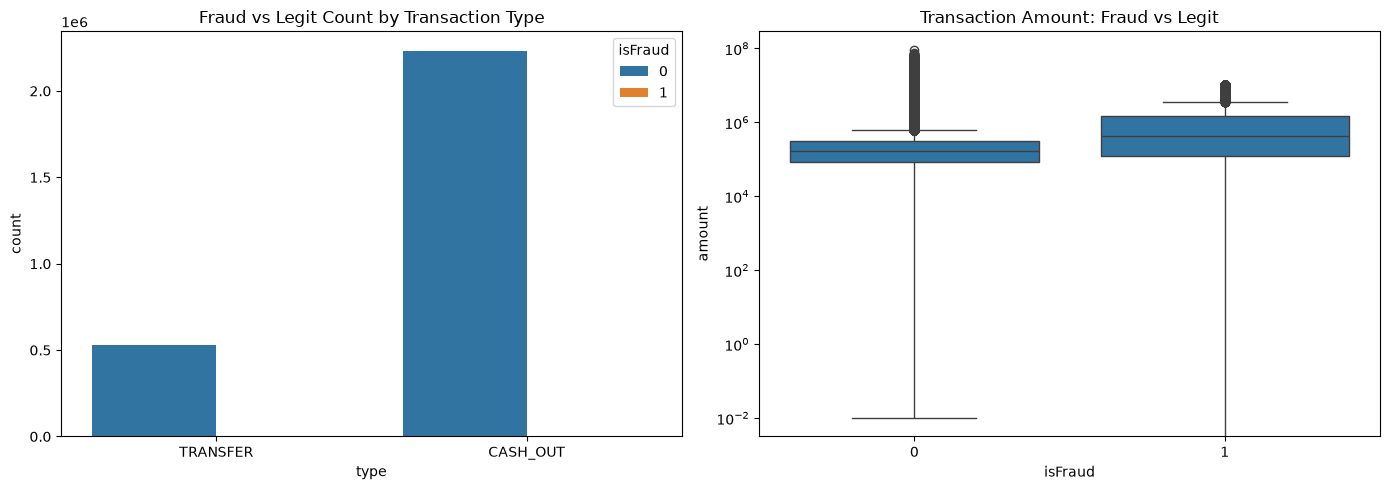

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=relevant, x='type', hue='isFraud', ax=axes[0])
axes[0].set_title('Fraud vs Legit Count by Transaction Type')

sns.boxplot(data=relevant, x='isFraud', y='amount', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount: Fraud vs Legit')

plt.tight_layout()
plt.show()

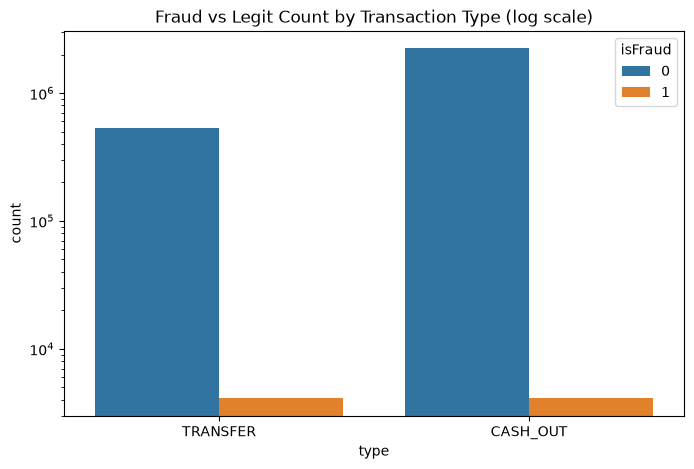

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=relevant, x='type', hue='isFraud', ax=ax)
ax.set_yscale('log')
ax.set_title('Fraud vs Legit Count by Transaction Type (log scale)')
plt.show()

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
relevant = relevant.copy()

relevant['errorBalanceOrig'] = relevant['oldbalanceOrg'] - relevant['amount'] - relevant['newbalanceOrig']
relevant['errorBalanceDest'] = relevant['oldbalanceDest'] + relevant['amount'] - relevant['newbalanceDest']
relevant['isDrainedToZero'] = (relevant['newbalanceOrig'] == 0).astype(int)
relevant['isMuleAccount'] = (relevant['oldbalanceDest'] == 0).astype(int)
relevant['hourOfDay'] = relevant['step'] % 24

relevant.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,isDrainedToZero,isMuleAccount,hourOfDay
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0,1,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0,1,0,1
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,-213808.94,182703.5,1,0,1
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,-214605.30,237735.3,1,0,1
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,-300850.89,-2401220.0,1,0,1


In [13]:
relevant.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe()

errorBalanceOrig                                             \
                   count           mean            std          min   
isFraud                                                               
0              2762196.0 -286803.509954  876375.192156 -92445516.64   
1                 8213.0  -10692.325265  265146.131130 -10000000.00   

                                                        errorBalanceDest  \
                25%         50%       75%           max            count   
isFraud                                                                    
0       -280466.255 -144200.825 -52613.43  1.000000e-02        2762196.0   
1             0.000       0.000      0.00  3.725290e-09           8213.0   

                                                                            \
                  mean           std          min  25%      50%        75%   
isFraud                                                                      
0        -30910.325352  5.840943e+05 -75885725.63  0.0     0.00       0.00   
1        732509.301069  1.867748e+06  -8875516.29  0.0  2231.46  442722.01   

                      
                 max  
isFraud               
0         9977761.06  
1        10000000.00

In [14]:
relevant = pd.get_dummies(relevant, columns=['type'], drop_first=True)
relevant.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,isDrainedToZero,isMuleAccount,hourOfDay,type_TRANSFER
2,1,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0,1,1,1,True
3,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0,1,0,1,False
15,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,-213808.94,182703.5,1,0,1,False
19,1,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,-214605.30,237735.3,1,0,1,True
24,1,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,-300850.89,-2401220.0,1,0,1,True


In [15]:
relevant = relevant.drop(columns=['nameOrig', 'nameDest'])
relevant['type_TRANSFER'] = relevant['type_TRANSFER'].astype(int)

relevant.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,isDrainedToZero,isMuleAccount,hourOfDay,type_TRANSFER
2,1,181.00,181.0,0.0,0.0,0.00,1,0,0.00,181.0,1,1,1,1
3,1,181.00,181.0,0.0,21182.0,0.00,1,0,0.00,21363.0,1,0,1,0
15,1,229133.94,15325.0,0.0,5083.0,51513.44,0,0,-213808.94,182703.5,1,0,1,0
19,1,215310.30,705.0,0.0,22425.0,0.00,0,0,-214605.30,237735.3,1,0,1,1
24,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,0,-300850.89,-2401220.0,1,0,1,1


In [16]:
correlations = relevant.corr()['isFraud'].sort_values(ascending=False)
correlations

isFraud             1.000000
oldbalanceOrg       0.347582
isMuleAccount       0.080177
amount              0.070660
errorBalanceDest    0.069935
newbalanceOrig      0.063557
step                0.048671
isFlaggedFraud      0.044072
type_TRANSFER       0.042400
errorBalanceOrig    0.017149
isDrainedToZero     0.014496
newbalanceDest     -0.008978
oldbalanceDest     -0.014960
hourOfDay          -0.051230
Name: isFraud, dtype: float64

In [17]:
relevant.groupby('isFraud')['isDrainedToZero'].mean()

isFraud
0    0.900951
1    0.980519
Name: isDrainedToZero, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split

X = relevant.drop(columns=['isFraud'])
y = relevant['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows, {y_train.sum()} fraud cases")
print(f"Test set: {X_test.shape[0]} rows, {y_test.sum()} fraud cases")

Training set: 2216327 rows, 6570 fraud cases
Test set: 554082 rows, 1643 fraud cases


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [20]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

errorBalanceOrig    0.432631
oldbalanceOrg       0.173021
newbalanceDest      0.086744
newbalanceOrig      0.057415
isDrainedToZero     0.057162
oldbalanceDest      0.042166
errorBalanceDest    0.036294
amount              0.030452
hourOfDay           0.027251
isMuleAccount       0.024121
step                0.021278
type_TRANSFER       0.010904
isFlaggedFraud      0.000564
dtype: float64

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

[[552438      1]
 [     5   1638]]
